### Taller 6 – Aprendizaje Supervisado

Aplicar técnicas de **preprocesamiento de datos** (tratamiento de variables categóricas y escalado de variables numéricas) y **entrenar 3 modelos de aprendizaje supervisado** para predecir si un pedido llegará a tiempo o no. Al final comparo los modelos con métricas y gráficas para decidir cuál es el mejor.

---
## Paso 0: Importación de librerías esenciales

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,        # accuracy: porcentaje de aciertos totales
                             precision_score,       # precision: de los que dije "tarde", cuántos realmente lo eran
                             recall_score,          # recall: de los que realmente llegaron tarde, cuántos detecté
                             f1_score,              # f1: un promedio que combina precision y recall
                             roc_auc_score,         # AUC: qué tan bien separa el modelo las dos clases (1.0 = perfecto, 0.5 = azar)
                             confusion_matrix,      # matriz de confusión: tabla de aciertos y errores
                             classification_report, # resumen de texto con varias métricas a la vez
                             roc_curve)             # datos para dibujar la curva ROC

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 11
print("Librerías importadas correctamente")

Librerías importadas correctamente


---
## 1. Carga de Datos y Análisis Exploratorio Inicial
### Paso 1: cargar el dataset

In [6]:
# encoding="utf-8-sig": el archivo trae un carácter invisible al inicio (llamado BOM) que dañaría el nombre de la primera columna;
df = pd.read_csv("BaseDeDatosTaller6.csv", encoding="utf-8-sig")
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


---
### 1.1 Exploración inicial: .head(), .info(), nulos y EDA

In [7]:
filas, columnas = df.shape
print("Número de filas (envíos):", filas)
print("Número de columnas (variables):", columnas)

Número de filas (envíos): 10999
Número de columnas (variables): 12


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [9]:
display(df.describe().round(2))

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00
mean,5500.00,4.05,2.99,210.20,3.57,13.37,3634.02,0.60
std,3175.28,1.14,1.41,48.06,1.52,16.21,1635.38,0.49
min,1.00,2.00,1.00,96.00,2.00,1.00,1001.00,0.00
25%,2750.50,3.00,2.00,169.00,3.00,4.00,1839.50,0.00
50%,5500.00,4.00,3.00,214.00,3.00,7.00,4149.00,1.00
75%,8249.50,5.00,4.00,251.00,4.00,10.00,5050.00,1.00
max,10999.00,7.00,5.00,310.00,10.00,65.00,7846.00,1.00


In [10]:
nulos = df.isnull().sum()
print(nulos)
print("\nTotal de datos vacíos:", nulos.sum())
print("Filas duplicadas:", df.duplicated().sum())

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

Total de datos vacíos: 0
Filas duplicadas: 0


El dataset está limpio, así que no necesito rellenar ni borrar nada por ese motivo. Empezamos a graficar para tener mejor visual de los datos y apoyarnos en las gráficas para las conclusiones

Cantidad de pedidos por clase:
Reached.on.Time_Y.N
1    6563
0    4436
Name: count, dtype: int64

Porcentaje por clase:
Reached.on.Time_Y.N
1    59.7
0    40.3
Name: proportion, dtype: float64


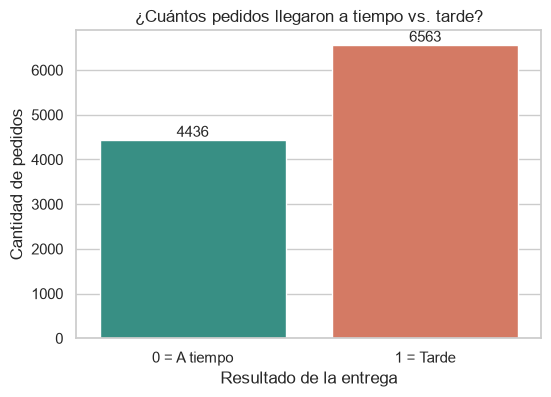

In [11]:
objetivo = "Reached.on.Time_Y.N"
conteo = df[objetivo].value_counts()
porcentaje = df[objetivo].value_counts(normalize=True) * 100
print("Cantidad de pedidos por clase:")
print(conteo)
print("\nPorcentaje por clase:")
print(porcentaje.round(1))

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=objetivo, hue=objetivo, data=df, palette=["#2a9d8f", "#e76f51"], legend=False)
plt.title("¿Cuántos pedidos llegaron a tiempo vs. tarde?")
plt.xticks([0, 1], ["0 = A tiempo", "1 = Tarde"])
plt.xlabel("Resultado de la entrega")
plt.ylabel("Cantidad de pedidos")
for contenedor in ax.containers:
    ax.bar_label(contenedor)
plt.show()

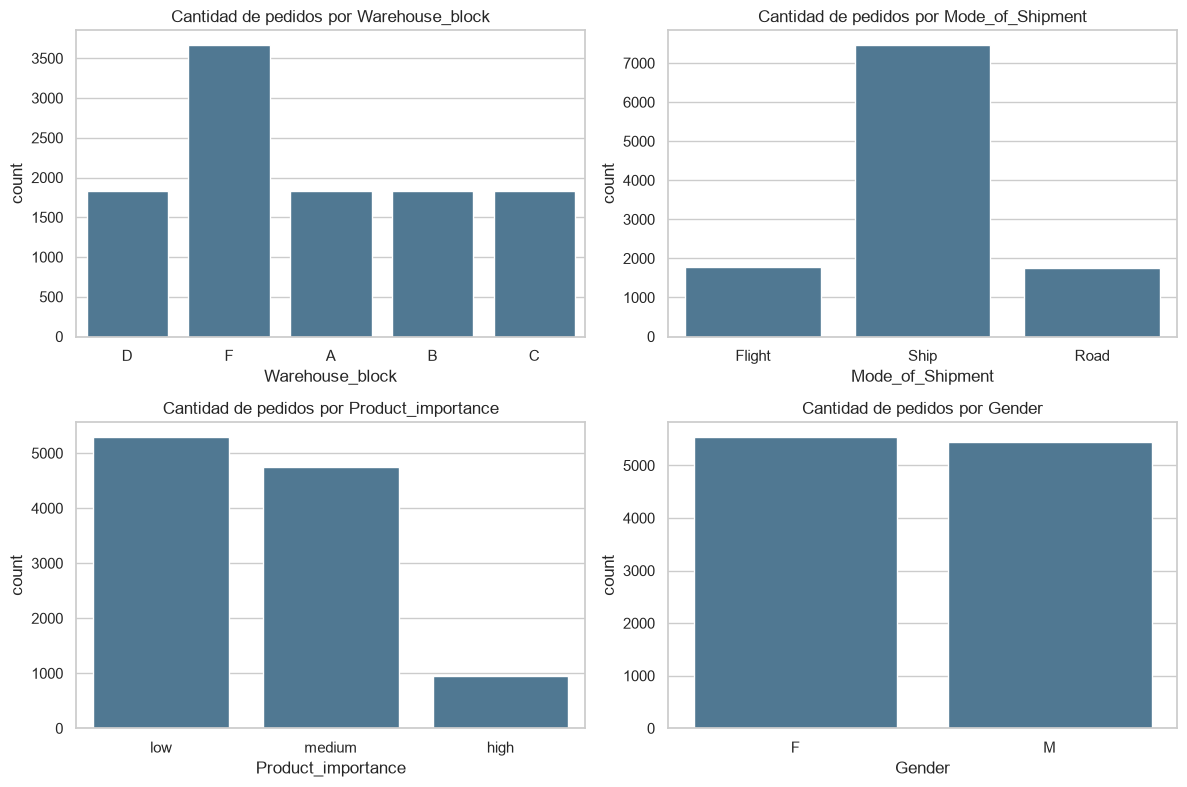

In [12]:
categoricas = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
numericas = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
             "Prior_purchases", "Discount_offered", "Weight_in_gms"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(categoricas):
    sns.countplot(x=col, data=df, ax=axes[i], color="#457b9d")
    axes[i].set_title(f"Cantidad de pedidos por {col}")
plt.tight_layout()
plt.show()

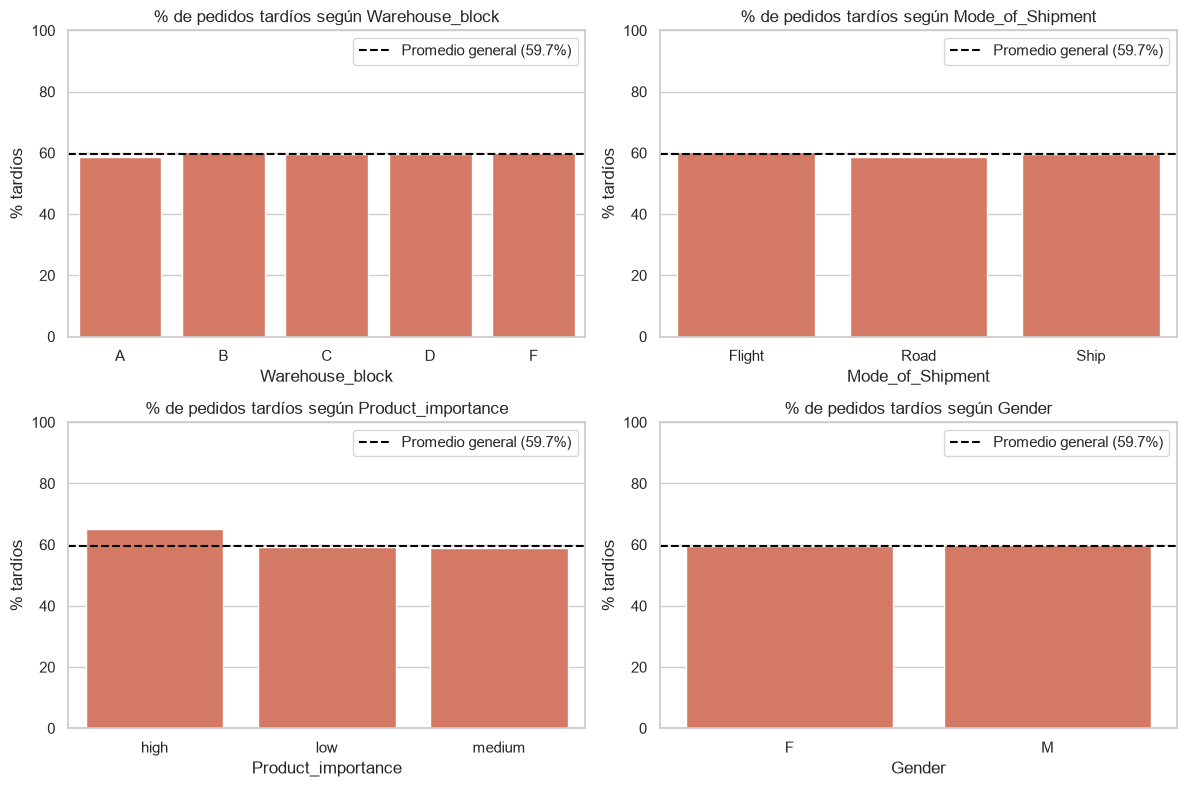

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
tarde_general = df[objetivo].mean() * 100
for i, col in enumerate(categoricas):
    tasa = df.groupby(col)[objetivo].mean() * 100
    sns.barplot(x=tasa.index, y=tasa.values, ax=axes[i], color="#e76f51")
    axes[i].axhline(tarde_general, color="black", linestyle="--", label=f"Promedio general ({tarde_general:.1f}%)")
    axes[i].set_title(f"% de pedidos tardíos según {col}")
    axes[i].set_ylabel("% tardíos")
    axes[i].set_ylim(0, 100)
    axes[i].legend()
plt.tight_layout()
plt.show()

El porcentaje de tardíos es casi igual en todas las categorías todas rondan el 59-60%. Solo `Product_importance = high` sube un poco 65%. O sea, las variables categóricas por sí solas dan pocas pistas. La información importante debe estar en las variables numéricas.



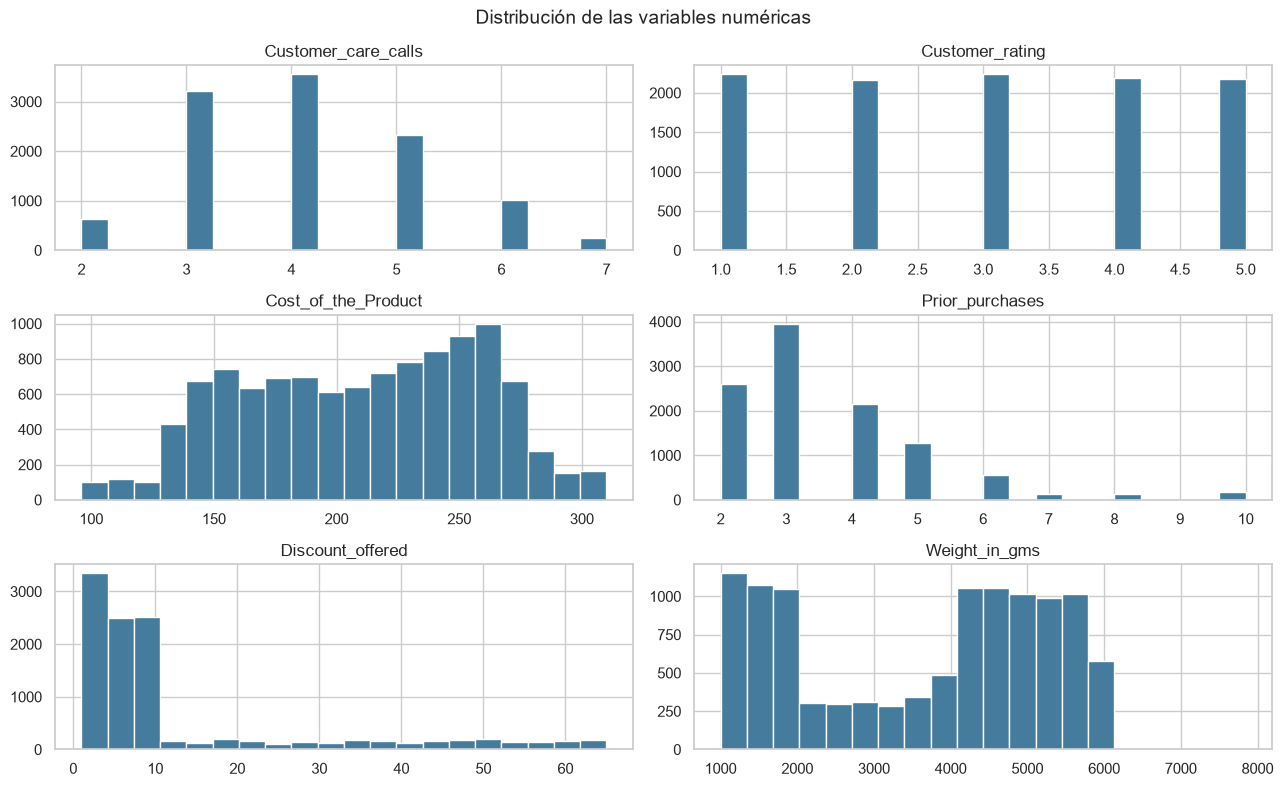

In [14]:
df[numericas].hist(bins=20, figsize=(13, 8), color="#457b9d")
plt.suptitle("Distribución de las variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

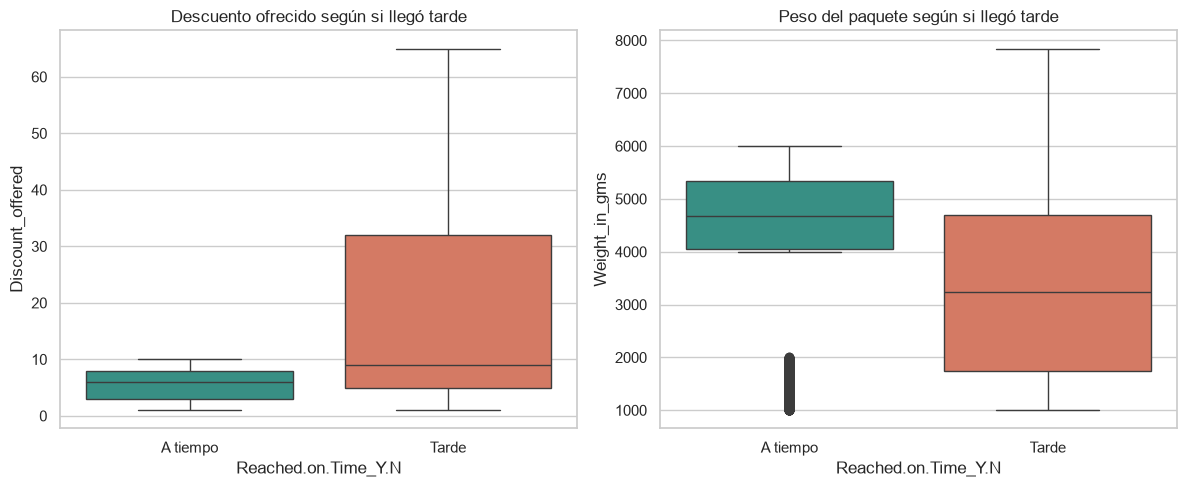

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x=objetivo, y="Discount_offered", data=df, ax=axes[0], hue=objetivo, palette=["#2a9d8f", "#e76f51"], legend=False)
axes[0].set_title("Descuento ofrecido según si llegó tarde")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["A tiempo", "Tarde"])
sns.boxplot(x=objetivo, y="Weight_in_gms", data=df, ax=axes[1], hue=objetivo, palette=["#2a9d8f", "#e76f51"], legend=False)
axes[1].set_title("Peso del paquete según si llegó tarde")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["A tiempo", "Tarde"])
plt.tight_layout()
plt.show()

Los pedidos que llegan tarde tienen descuentos mucho más altos y suelen ser paquetes más livianos. Vamos a mirar esto con más detalle agrupando en rangos

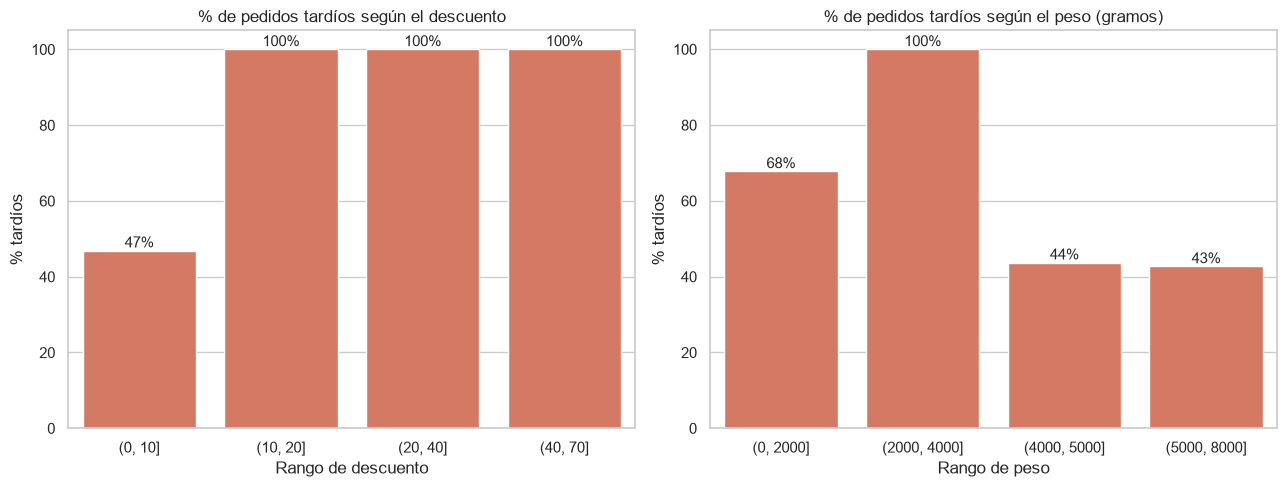

In [16]:
rangos_descuento = pd.cut(df["Discount_offered"], bins=[0, 10, 20, 40, 70])
rangos_peso = pd.cut(df["Weight_in_gms"], bins=[0, 2000, 4000, 5000, 8000])

tasa_desc = df.groupby(rangos_descuento)[objetivo].mean() * 100
tasa_peso = df.groupby(rangos_peso)[objetivo].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=tasa_desc.index.astype(str), y=tasa_desc.values, ax=axes[0], color="#e76f51")
axes[0].set_title("% de pedidos tardíos según el descuento"); axes[0].set_xlabel("Rango de descuento"); axes[0].set_ylabel("% tardíos")
sns.barplot(x=tasa_peso.index.astype(str), y=tasa_peso.values, ax=axes[1], color="#e76f51")
axes[1].set_title("% de pedidos tardíos según el peso (gramos)"); axes[1].set_xlabel("Rango de peso"); axes[1].set_ylabel("% tardíos")
for ax in axes:
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt="%.0f%%")
plt.tight_layout()
plt.show()

- Cuando el descuento es mayor a 10, el 100% de los pedidos llegó tarde. Con descuento ≤ 10 solo 47% llega tarde.
- Los paquetes de 2000 a 4000 g llegan tarde casi el 100% de las veces, mientras que los más pesados >4000 g llegan tarde mucho menos 43-44%
- La relación con el peso no es una línea recta. Esto es importante porque un modelo como la Regresión Logística lo va a tener difícil, mientras que los modelos basados en árboles deberían aprovecharlo mejor
### 1.2 Correlación entre variables numéricas
La correlación mide qué tanto suben o bajan dos variables juntas (va de -1 a +1; cerca de 0 = no se parecen).

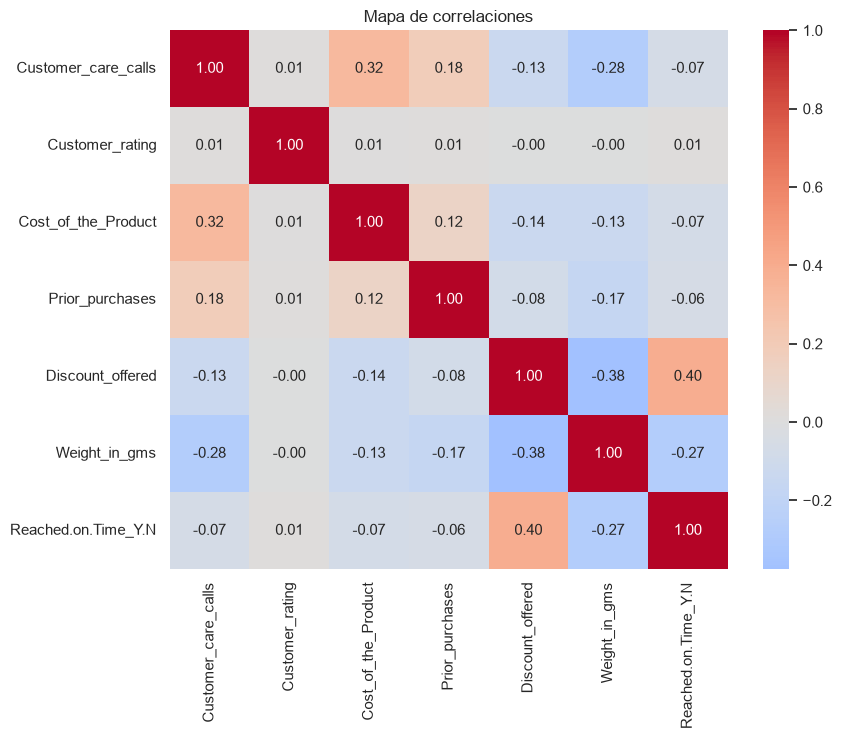

In [17]:
correlacion = df[numericas + [objetivo]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de correlaciones")
plt.show()

Las variables con mayor relación con llegar tarde son `Discount_offered` correlación +0.40, a más descuento más probable llegar tarde y `Weight_in_gms` -0.27, a más peso menos probable llegar tarde. Las demás tienen correlaciones muy pequeñas menos de 0.08 en valor absoluto.

---
## 2. Preprocesamiento de Datos e Ingeniería de Características

Identificación y transformación de variables categóricas

In [18]:
df_modelo = df.drop(columns=["ID"])
print("Columnas que quedan:", list(df_modelo.columns))

Columnas que quedan: ['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N']


Pregunta de la guía: ¿tiene un orden lógico? Sí. Como hay una jerarquía, uso una codificación ordinal que la conserva: `low = 1`, `medium = 2`, `high = 3`.

Si usara One-Hot aquí, perdería esa información de orden.

In [19]:
orden_importancia = {"low": 1, "medium": 2, "high": 3}
df_modelo["Product_importance"] = df_modelo["Product_importance"].map(orden_importancia)
print(df_modelo["Product_importance"].value_counts().sort_index())
print("Valores vacíos después de codificar:", df_modelo["Product_importance"].isnull().sum())

Product_importance
1    5297
2    4754
3     948
Name: count, dtype: int64
Valores vacíos después de codificar: 0


¿Tienen orden lógico? No. Si les pusiera 1, 2, 3, el modelo creería que unos valen más que otros. Por eso uso One-Hot Encoding y creo una columna nueva por cada categoría con 1 sí es o 0 no es

In [20]:
cols_onehot = ["Mode_of_Shipment", "Warehouse_block", "Gender"]
df_modelo = pd.get_dummies(df_modelo, columns=cols_onehot, drop_first=True, dtype=int)
print("Columnas después de codificar:")
print(list(df_modelo.columns))
print("\nNúmero de columnas ahora:", df_modelo.shape[1])
df_modelo.head()

Columnas después de codificar:
['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms', 'Reached.on.Time_Y.N', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Gender_M']

Número de columnas ahora: 15


,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Gender_M
0,4,2,177,3,1,44,1233,1,0,0,0,0,1,0,0
1,4,5,216,2,1,59,3088,1,0,0,0,0,0,1,1
2,2,2,183,4,1,48,3374,1,0,0,0,0,0,0,1
3,3,3,176,4,2,10,1177,1,0,0,1,0,0,0,1
4,2,2,184,3,2,46,2484,1,0,0,0,1,0,0,0


Definir la matriz de características X y el vector objetivo y
- X = todas las columnas que el modelo usará como pistas.
- y = la columna que el modelo debe adivinar: `Reached.on.Time_Y.N`.

In [21]:
X = df_modelo.drop(columns=[objetivo])
y = df_modelo[objetivo]
print("Tamaño de X (filas, columnas):", X.shape)
print("Tamaño de y (filas,):", y.shape)

Tamaño de X (filas, columnas): (10999, 14)
Tamaño de y (filas,): (10999,)


---
## 3. División del Dataset

El modelo estudia con el 80% de los datos (train) y luego lo examino con el 20% restante (test) que nunca ha visto.

Configuro `test_size=0.2` (20%) y un `random_state` fijo (42) para que mis resultados sean **replicables**.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                 
    test_size=0.2,        
    random_state=42,      
    stratify=y)           

print("Filas en entrenamiento:", X_train.shape[0])
print("Filas en prueba:", X_test.shape[0])
print("\n% de tardíos en train:", round(y_train.mean() * 100, 1))
print("% de tardíos en test:", round(y_test.mean() * 100, 1))

Filas en entrenamiento: 8799
Filas en prueba: 2200

% de tardíos en train: 59.7
% de tardíos en test: 59.7


Escalado de variables numéricas
Mira los rangos: `Weight_in_gms` va de 1000 a 7800 y `Customer_care_calls` va de 2 a 7. Para algunos modelos sobre todo la Regresión Logística las columnas con números grandes "pesan más" solo por su tamaño, no por su importancia real. El escalado lo arregla.

Uso StandardScaler, que transforma cada columna para que quede con promedio 0 y desviación estándar 1. La fórmula es: `(valor - promedio) / desviación_estándar`.

In [23]:
X_train = X_train.copy()
X_test = X_test.copy()
escalador = StandardScaler()

X_train[numericas] = escalador.fit_transform(X_train[numericas])
X_test[numericas] = escalador.transform(X_test[numericas])

print("Promedio de las columnas escaladas en train (debe ser ~0):")
print(X_train[numericas].mean().round(3))
print("\nDesviación estándar en train (debe ser ~1):")
print(X_train[numericas].std().round(3))

Promedio de las columnas escaladas en train (debe ser ~0):
Customer_care_calls   -0.0
Customer_rating        0.0
Cost_of_the_Product    0.0
Prior_purchases       -0.0
Discount_offered       0.0
Weight_in_gms          0.0
dtype: float64

Desviación estándar en train (debe ser ~1):
Customer_care_calls    1.0
Customer_rating        1.0
Cost_of_the_Product    1.0
Prior_purchases        1.0
Discount_offered       1.0
Weight_in_gms          1.0
dtype: float64


In [24]:
#Miramos la tabla final que recibirán los modelos: todo son números y las numéricas ya están escaladas.
X_train.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Gender_M
7920,-0.043121,-1.415468,1.056631,-1.032208,2,-0.270466,0.322365,1,0,0,0,1,0,0
1529,-0.921405,0.001852,-1.003783,-1.032208,1,0.782420,-1.206929,0,1,0,0,0,1,0
10521,-0.921405,-0.706808,0.224140,-1.032208,2,-0.270466,0.510849,0,1,1,0,0,0,1
9558,-0.921405,1.419173,-1.107845,0.272734,2,-0.704008,0.617330,0,1,0,0,1,0,0
968,-1.799688,1.419173,1.285566,-1.032208,1,0.658551,0.004144,0,0,0,0,0,0,1


---
## 4. Entrenamiento de Modelos
Vamos a entrenar tres modelos distintos, del más simple al más complejo. Entrenar (con `.fit()`) significa mostrarle al modelo los datos de train las pistas `X_train` con sus respuestas `y_train` para que descubra patrones. Luego predecir (con `.predict()`) es pedirle que adivine las respuestas de `X_test`, datos que nunca vio.

In [25]:
arbol_sin_limite = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print("Accuracy en TRAIN (datos que estudió):", round(arbol_sin_limite.score(X_train, y_train), 3))
print("Accuracy en TEST  (examen sorpresa):  ", round(arbol_sin_limite.score(X_test, y_test), 3))
print("Profundidad que alcanzó el árbol:", arbol_sin_limite.get_depth())

Accuracy en TRAIN (datos que estudió): 1.0
Accuracy en TEST  (examen sorpresa):   0.629
Profundidad que alcanzó el árbol: 34


El árbol sin límite saca 100% en train pero solo ~63% en test. Eso es sobreajuste, memorizó en vez de aprender. Para evitarlo, en el modelo final le limito la profundidad (`max_depth`), obligándolo a aprender solo patrones generales. Hago lo mismo con el Random Forest.

#### Modelo 1: Regresión Logística

In [26]:
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)
print("Primeras 10 predicciones:", pred_lr[:10])
print("Primeras 10 respuestas reales:", y_test.values[:10])

Primeras 10 predicciones: [1 0 0 0 0 1 1 0 0 1]
Primeras 10 respuestas reales: [1 1 0 0 0 1 0 1 0 1]


#### Modelo 2: Árbol de Decisión

In [27]:
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)
pred_arbol = modelo_arbol.predict(X_test)
print("Primeras 10 predicciones:", pred_arbol[:10])
print("Primeras 10 respuestas reales:", y_test.values[:10])

Primeras 10 predicciones: [1 0 0 0 0 0 0 0 0 1]
Primeras 10 respuestas reales: [1 1 0 0 0 1 0 1 0 1]


#### Modelo 3: Random Forest

In [28]:
modelo_rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)
print("Primeras 10 predicciones:", pred_rf[:10])
print("Primeras 10 respuestas reales:", y_test.values[:10])

Primeras 10 predicciones: [1 1 0 0 0 0 0 1 0 1]
Primeras 10 respuestas reales: [1 1 0 0 0 1 0 1 0 1]


---
## 5. Evaluación y Comparación de Resultados
comparo las predicciones de cada modelo con las respuestas reales `y_test`.

Explicación de las métricas:

- Accuracy (exactitud): de todos los pedidos, ¿qué % clasificó bien? *(Sirve como medida general porque las clases están relativamente balanceadas.)
- Matriz de confusión: tabla que cuenta aciertos y errores: verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
- Precision (precisión): cuando el modelo dice "este pedido llegará tarde", ¿qué % de las veces acierta? *(Alta precisión = pocas falsas alarmas.)
- Recall (sensibilidad): de todos los pedidos que realmente llegaron tarde, ¿qué % logró detectar? *(Alto recall = se le escapan pocos pedidos tardíos.)
- F1-score: un solo número que combina precision y recall (si uno de los dos es bajo, el F1 también baja).
- AUC-ROC: mide qué tan bien el modelo separa los pedidos tardíos de los puntuales, sin importar el umbral de decisión. 0.5 = adivinar al azar, 1.0 = perfecto.

### Paso 5: Cálculo de métricas para cada modelo
Uso `accuracy_score`, `confusion_matrix` y `classification_report`, y guardo los Accuracy en un diccionario y luego en un DataFrame para poder graficarlos fácilmente

In [29]:
predicciones = {
    "Regresión Logística": pred_lr,
    "Árbol de Decisión": pred_arbol,
    "Random Forest": pred_rf,
}

accuracies = {}

for nombre, pred in predicciones.items():
    acc = accuracy_score(y_test, pred)
    accuracies[nombre] = acc
    print("=" * 60)
    print(nombre)
    print("=" * 60)
    print("Accuracy:", round(acc, 3))
    print("\nMatriz de confusión (números crudos):")
    print(confusion_matrix(y_test, pred))
    print("\nReporte de clasificación:")
    print(classification_report(y_test, pred, target_names=["A tiempo (0)", "Tarde (1)"]))

df_acc = pd.DataFrame({"Modelo": list(accuracies.keys()), "Accuracy": list(accuracies.values())})
df_acc

Regresión Logística
Accuracy: 0.64

Matriz de confusión (números crudos):
[[524 363]
 [428 885]]

Reporte de clasificación:
              precision    recall  f1-score   support

A tiempo (0)       0.55      0.59      0.57       887
   Tarde (1)       0.71      0.67      0.69      1313

    accuracy                           0.64      2200
   macro avg       0.63      0.63      0.63      2200
weighted avg       0.65      0.64      0.64      2200

Árbol de Decisión
Accuracy: 0.68

Matriz de confusión (números crudos):
[[867  20]
 [685 628]]

Reporte de clasificación:
              precision    recall  f1-score   support

A tiempo (0)       0.56      0.98      0.71       887
   Tarde (1)       0.97      0.48      0.64      1313

    accuracy                           0.68      2200
   macro avg       0.76      0.73      0.68      2200
weighted avg       0.80      0.68      0.67      2200

Random Forest
Accuracy: 0.681

Matriz de confusión (números crudos):
[[837  50]
 [651 662]]

Reporte

,Modelo,Accuracy
0,Regresión Logística,0.640455
1,Árbol de Decisión,0.679545
2,Random Forest,0.681364


#### Tabla completa de métricas
Además del Accuracy, calculo precision, recall, F1 y AUC de cada modelo, y el Accuracy en train para revisar sobreajuste. Así tengo todo junto para decidir cuál es el mejor.

In [30]:
modelos = {
    "Regresión Logística": modelo_lr,
    "Árbol de Decisión": modelo_arbol,
    "Random Forest": modelo_rf,
}
probabilidades = {}
resultados = []

for nombre, modelo in modelos.items():
    pred = predicciones[nombre]
    proba = modelo.predict_proba(X_test)[:, 1]
    probabilidades[nombre] = proba
    resultados.append({
        "Modelo": nombre,
        "Accuracy Train": modelo.score(X_train, y_train),   
        "Accuracy Test": accuracies[nombre],                 
        "Precision": precision_score(y_test, pred),         
        "Recall": recall_score(y_test, pred),                
        "F1": f1_score(y_test, pred),                       
        "AUC": roc_auc_score(y_test, proba),                 
    })

tabla = pd.DataFrame(resultados).set_index("Modelo")
display(tabla.round(3))

,Accuracy Train,Accuracy Test,Precision,Recall,F1,AUC
Modelo,,,,,,
Regresión Logística,0.639,0.640,0.709,0.674,0.691,0.717
Árbol de Decisión,0.692,0.680,0.969,0.478,0.640,0.736
Random Forest,0.732,0.681,0.930,0.504,0.654,0.746


### Paso 6: Gráfica comparativa de Accuracy
Gráfico de barras donde el eje X son los modelos y el eje Y es el Accuracy obtenido.

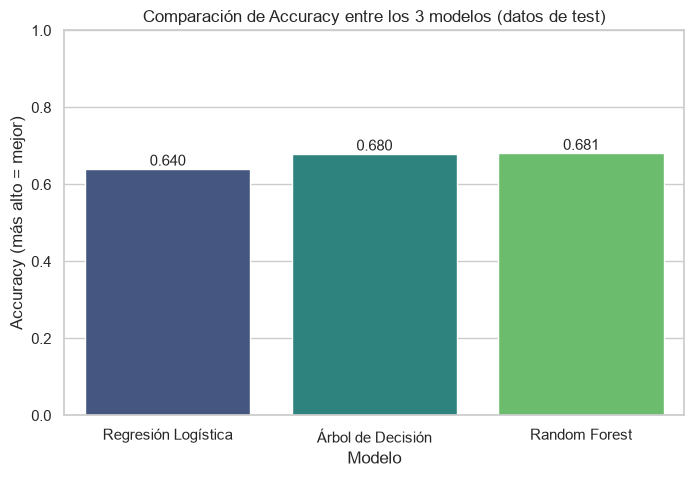

In [31]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Modelo", y="Accuracy", hue="Modelo", data=df_acc, palette="viridis", legend=False)
plt.title("Comparación de Accuracy entre los 3 modelos (datos de test)")
plt.ylabel("Accuracy (más alto = mejor)")
plt.xlabel("Modelo")
plt.ylim(0, 1)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.3f")
plt.show()

El Árbol de Decisión y el Random Forest empatan prácticamente en Accuracy 0.68 y superan a la Regresión Logística 0.64. Pero el Accuracy solo cuenta aciertos totales; abajo reviso qué tipo de errores comete cada uno.

### Paso 7: Matrices de Confusión
Cada casilla cuenta pedidos. Filas = lo que realmente pasó; columnas = lo que dijo el modelo. Esto permite analizar visualmente los falsos positivos y falsos negativos:
- Arriba-izquierda: dijo "a tiempo" y así fue  (verdadero negativo)
- Abajo-derecha: dijo "tarde" y así fue  (verdadero positivo)
- Arriba-derecha: dijo "tarde" pero llegó a tiempo  (falso positivo = falsa alarma)
- Abajo-izquierda: dijo "a tiempo" pero llegó tarde  (falso negativo = tardío no detectado)

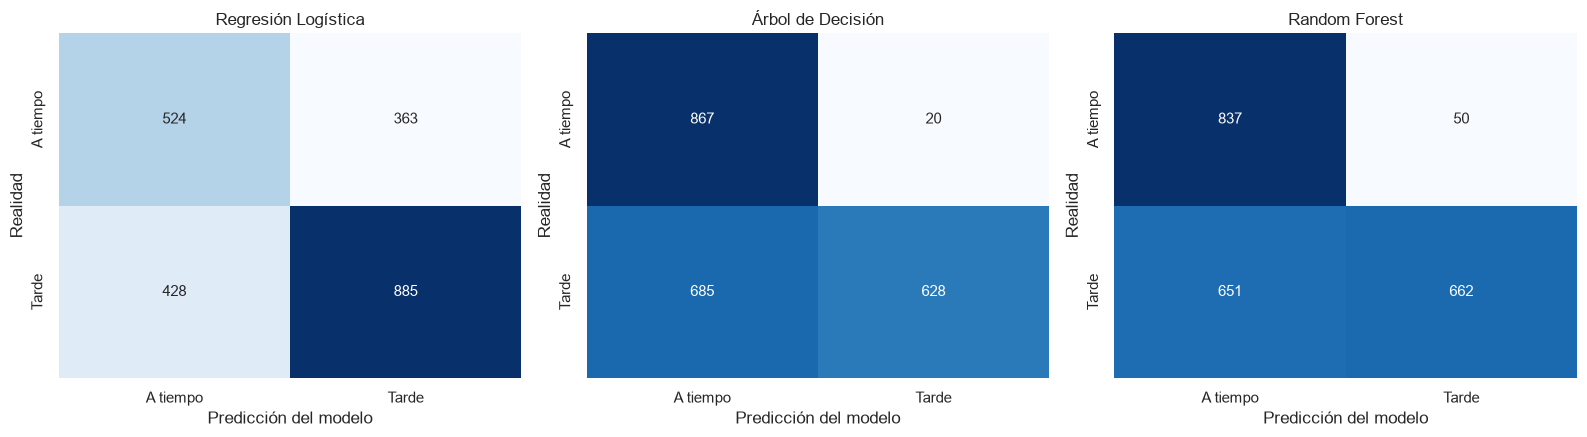

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, nombre in enumerate(predicciones.keys()):
    cm = confusion_matrix(y_test, predicciones[nombre])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i],
                xticklabels=["A tiempo", "Tarde"], yticklabels=["A tiempo", "Tarde"])
    axes[i].set_title(nombre)
    axes[i].set_xlabel("Predicción del modelo")
    axes[i].set_ylabel("Realidad")
plt.tight_layout()
plt.show()

- La Regresión Logística reparte sus errores de forma pareja: comete tanto falsas alarmas como tardíos no detectados.
- El Árbol y el Random Forest casi no dan falsas alarmas (esquina arriba-derecha muy baja), pero se les escapan muchos pedidos tardíos (esquina abajo-izquierda alta).


## Gráficas adicionales para justificar el mejor modelo


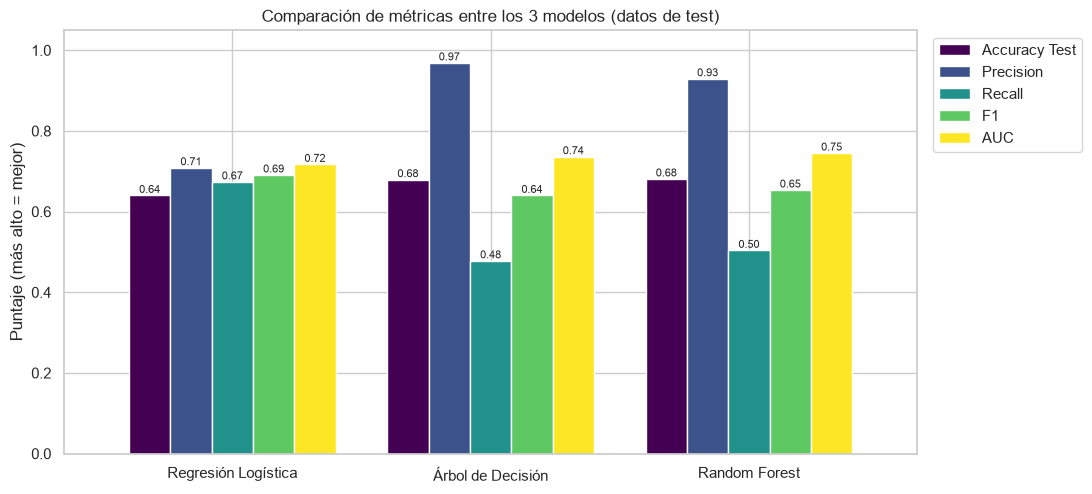

In [33]:
metricas_plot = tabla[["Accuracy Test", "Precision", "Recall", "F1", "AUC"]]
ax = metricas_plot.plot(kind="bar", figsize=(11, 5.5), colormap="viridis", width=0.8)
plt.title("Comparación de métricas entre los 3 modelos (datos de test)")
plt.ylabel("Puntaje (más alto = mejor)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.2f", fontsize=8)
plt.show()

### Curva ROC
Muestra el balance entre detectar pedidos tardíos eje Y y dar falsas alarmas eje X al ir cambiando el umbral de decisión. Una curva que se pega a la esquina superior izquierda es mejor. La línea punteada diagonal es adivinar al azar.

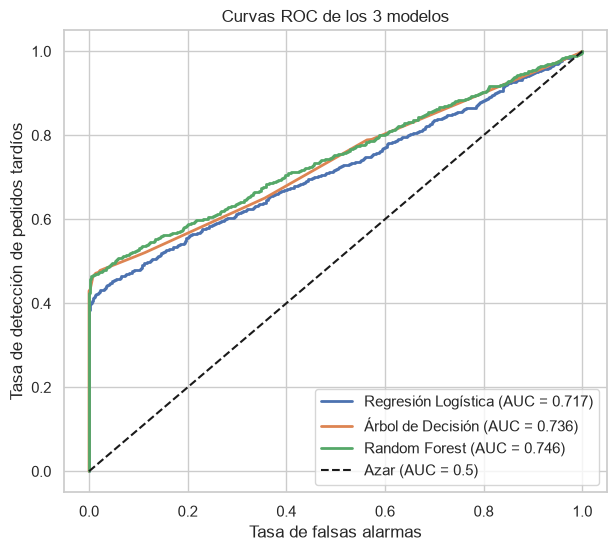

In [34]:
plt.figure(figsize=(7, 6))
for nombre in modelos.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilidades[nombre])
    plt.plot(fpr, tpr, linewidth=2, label=f"{nombre} (AUC = {tabla.loc[nombre, 'AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Azar (AUC = 0.5)")
plt.title("Curvas ROC de los 3 modelos")
plt.xlabel("Tasa de falsas alarmas")
plt.ylabel("Tasa de detección de pedidos tardíos")
plt.legend(loc="lower right")
plt.show()

### ¿Hay sobreajuste? Train vs. Test
Comparo el accuracy en los datos de entrenamiento contra los de prueba. Si la diferencia es grande, el modelo memorizó en vez de aprender.

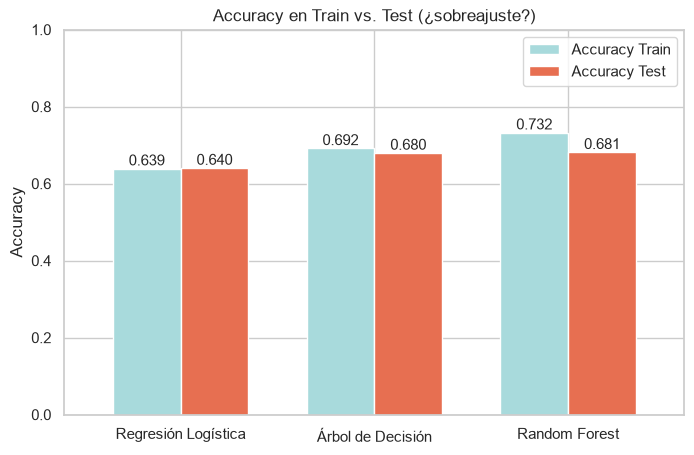

In [35]:
ax = tabla[["Accuracy Train", "Accuracy Test"]].plot(kind="bar", figsize=(8, 5), color=["#a8dadc", "#e76f51"], width=0.7)
plt.title("Accuracy en Train vs. Test (¿sobreajuste?)")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.xlabel("")
plt.ylim(0, 1)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.3f")
plt.show()

### ¿Qué variables usa el Random Forest para decidir?
Los árboles pueden decirnos qué pistas fueron más importantes (`feature_importances_`): un número por columna, y todos suman 1.

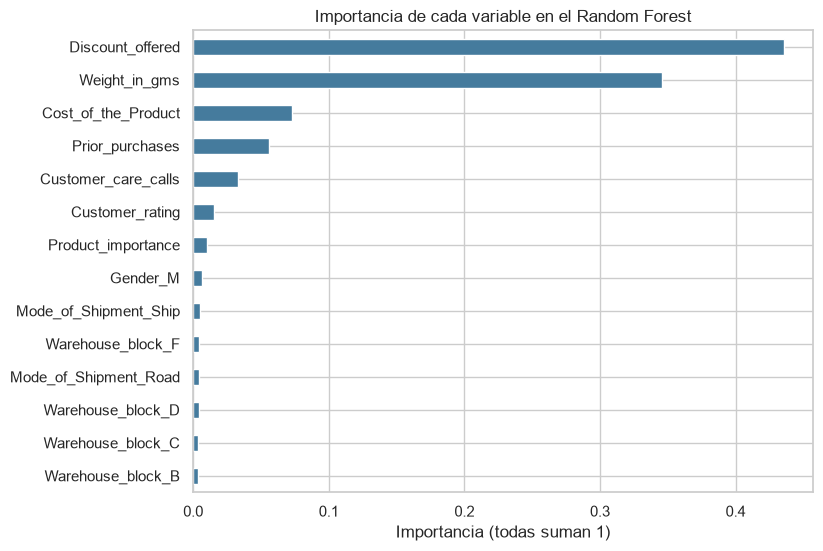

Top 3 variables más importantes:
Discount_offered       0.435
Weight_in_gms          0.346
Cost_of_the_Product    0.073
dtype: float64


In [36]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(8, 6))
importancias.plot(kind="barh", color="#457b9d")
plt.title("Importancia de cada variable en el Random Forest")
plt.xlabel("Importancia (todas suman 1)")
plt.show()
print("Top 3 variables más importantes:")
print(importancias.sort_values(ascending=False).head(3).round(3))

---
## 6. Elección del mejor modelo y conclusiones

### Tabla resumen

| Modelo | Accuracy | Precision | Recall | F1 | AUC | Accuracy Train |
|---|---|---|---|---|---|---|
| Regresión Logística | 0.640 | 0.709 | **0.674** | **0.691** | 0.717 | 0.639 |
| Árbol de Decisión (prof. 5) | 0.680 | **0.969** | 0.478 | 0.640 | 0.736 | 0.692 |
| **Random Forest** | **0.681** | 0.930 | 0.504 | 0.654 | **0.746** | 0.732 |

### Modelo elegido: Random Forest

Como las clases están relativamente balanceadas 60/40, tomé como métricas principales el Accuracy y el AUC (que mide qué tan bien separa el modelo las dos clases sin depender de un umbral), y como apoyo miré precision, recall, F1 y el sobreajuste.

Por qué gana el Random Forest?:
1. Tiene el mejor AUC (0.746), superior al Árbol 0.736 y a la Regresión Logística 0.717, en la curva ROC su línea es la que más se acerca a la esquina superior izquierda.
2. Empata con el Árbol en el mejor accuracy, 0.681 vs 0.680, y supera claramente a la Regresión Logística 0.64.
3. Tiene una precision muy alta 0.93, cuando avisa que un pedido llegará tarde, acierta el 93% de las veces.
4. Es más estable que un solo árbol porque combina 200 árboles que votan.
